### BÀI TẬP 1: 
Tìm và tải một bức ảnh màu có hình xe ô tô (xe chỉ có 1 màu) và lưu tên là input.jpg. Viết chương trình để:
1. Đọc ảnh vào bằng OpenCV.
2. Cắt lấy một vùng ảnh (ROI) có chứa xe ô tô.
3. Lưu vùng ảnh vừa cắt được thành một tệp mới tên là roi_output.jpg.

True

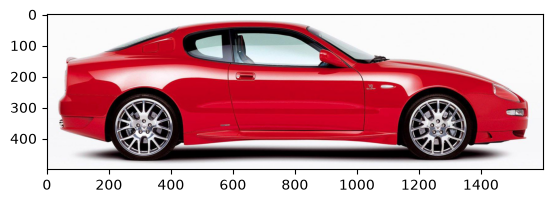

In [56]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
img = cv2.imread("./imgs/input.jpg")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# ROI
roi = img[400:900,:1700]
roi_img_rgb = cv2.cvtColor(roi, cv2.COLOR_BGR2RGB)

plt.imshow(roi_img_rgb)

cv2.imwrite("./imgs/roi_input.jpg", roi)


### BÀI TẬP 2: 

Cùng tệp ảnh input.jpg trên.
1. Thay đổi kích thước 512x512 pixel, gồm 3 kênh màu.
2. Vẽ một khung chữ nhật màu xanh lá cây (Green) bao quanh vùng có xe ô tô.
3. Chèn dòng chữ "car" màu đỏ, độ dày nét chữ là 2, nằm ngay bên trên khung.

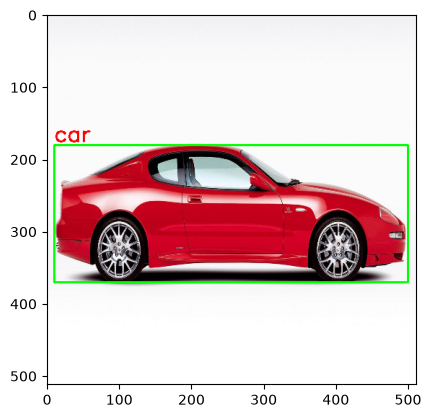

In [12]:
# resize
resize_img = cv2.resize(img,(512,512))
resize_img_rgb = cv2.cvtColor(resize_img, cv2.COLOR_BGR2RGB)

# green line covers car
cv2.rectangle(img=resize_img_rgb,pt1=(10,180),pt2=(500,370),thickness=2,color=(0,255,0))

# insert texts
cv2.putText(img=resize_img_rgb,text='car',org=(10,175),
            fontFace=cv2.FONT_HERSHEY_SIMPLEX, fontScale=1.0,color=(255,0,0), thickness=2)

plt.imshow(resize_img_rgb)

### BÀI TẬP 3:

Hãy chuyển ảnh sang không gian màu HSV và tạo một mặt nạ (Mask) để chỉ giữ lại chiếc xe, các vùng màu khác biến thành màu đen.

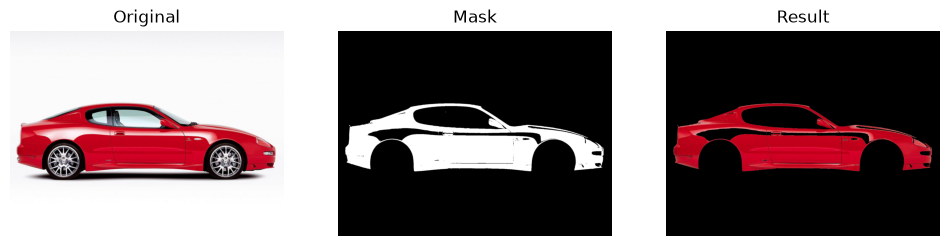

In [ ]:
# import cv2
# import numpy as np
# import matplotlib.pyplot as plt

# img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

# # 3. Xác định khoảng màu đỏ trong HSV
# lower_red1 = np.array([0, 100, 100])
# upper_red1 = np.array([10, 255, 255])

# lower_red2 = np.array([170, 100, 100])
# upper_red2 = np.array([179, 255, 255])


# mask1 = cv2.inRange(img_hsv, lower_red1, upper_red1)
# mask2 = cv2.inRange(img_hsv, lower_red2, upper_red2)

# mask = cv2.bitwise_or(mask1, mask2)

# # 5. Dùng mask để giữ lại chiếc xe
# result = cv2.bitwise_and(img, img, mask=mask)

# # 6. Chuyển BGR → RGB để matplotlib hiển thị đúng màu
# result_rgb = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)

# # 7. Hiển thị
# plt.figure(figsize=(12, 4))

# plt.subplot(1, 3, 1)
# plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
# plt.title("Original")
# plt.axis("off")

# plt.subplot(1, 3, 2)
# plt.imshow(mask, cmap="gray")
# plt.title("Mask")
# plt.axis("off")

# plt.subplot(1, 3, 3)
# plt.imshow(result_rgb)
# plt.title("Result")
# plt.axis("off")

# plt.show()

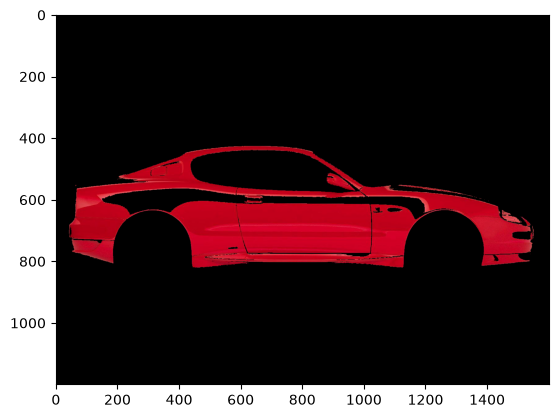

In [71]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img_hsv = cv2.cvtColor(img,cv2.COLOR_BGR2HSV)

lower_red1 = np.array([0,150,150])
upper_red1 = np.array([10,255,255])

lower_red2= np.array([170,150,150])
upper_red2 = np.array([179,255,255])

mask1 = cv2.inRange(img_hsv,lower_red1,upper_red1)
mask2 = cv2.inRange(img_hsv,lower_red2,upper_red2)

mask = cv2.bitwise_or(mask1,mask2)

red_mask = cv2.bitwise_and(img,img,mask=mask)
img_red_mask_rgb = cv2.cvtColor(red_mask, cv2.COLOR_BGR2RGB)
plt.imshow(img_red_mask_rgb, cmap="gray")

### BÀI TẬP 4:
Tìm một ảnh chụp một tờ giấy văn bản trên bàn và lưu tên document.jpg. Tìm ra ranh giới của tờ giấy:
1. Chuyển ảnh màu sang ảnh xám.
2. Làm mờ ảnh bằng Gaussian Blur để khử nhiễu (kích thước kernel $5 \times 5$).
3. Phát hiện cạnh bằng thuật toán Canny với ngưỡng (Threshold) là 50 và 150.

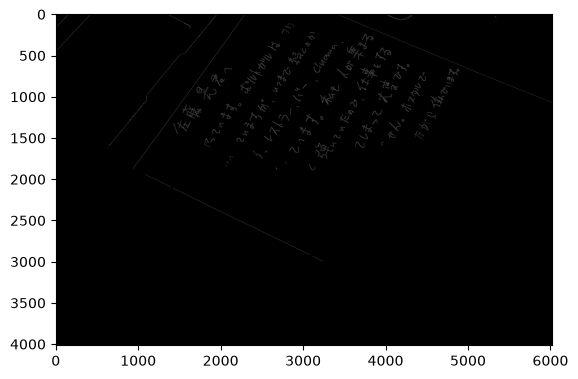

In [80]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("./imgs/document.jpg")

gray_img = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

blurred = cv2.GaussianBlur(gray_img,(5,5),0)

edges = cv2.Canny(blurred,threshold1=50,threshold2=150)

plt.imshow(edges, cmap="gray")

### BÀI TẬP 5:
Tìm một bức ảnh chụp một nhóm người và lưu tên team.jpg. Hãy nạp bộ trọng số đã được huấn luyện sẵn của OpenCV (haarcascade_frontalface_default.xml). Tiến hành nhận diện các khuôn mặt và vẽ một Bounding Box (khung chữ nhật) màu Xanh Lam (Blue), độ dày 3 bao quanh từng khuôn mặt.

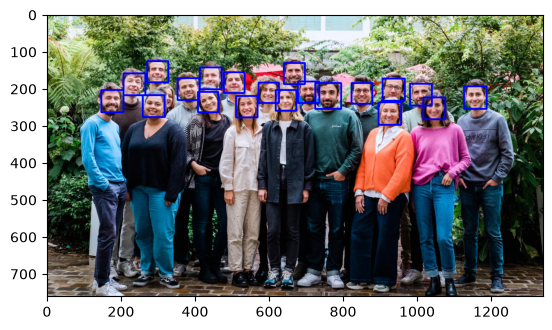

In [91]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


face_cascade = cv2.CascadeClassifier('./haarcascade_frontalface_default.xml')

img = cv2.imread("./imgs/team.jpg")

gray_img = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

faces =  face_cascade.detectMultiScale(gray_img, scaleFactor=1.2, minNeighbors=5)

for x,y,w,h in faces:
    cv2.rectangle(img, (x, y), (x + w, y + h), (255, 0, 0), 3)

plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))